In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
train_data = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test_data = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

In [79]:
train_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [80]:
train_data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [81]:
# --- 1. BÜTÜN NİTELİKLER İÇİN EKSİK DEĞER VE YÜZDE HESAPLAMASI ---

# Her sütundaki eksik değer sayısını bulma
eksik_sayilar = train_data.isnull().sum()

# Her sütundaki eksik değer yüzdesini bulma
eksik_yuzdeler = (train_data.isnull().sum() / len(train_data)) * 100

# Sonuçları okunaklı bir Pandas DataFrame (Tablo) haline getirme
eksik_veri_tablosu = pd.DataFrame({
    'Boş Değer Sayısı': eksik_sayilar,
    'Boş Değer Yüzdesi (%)': eksik_yuzdeler
})

# Hangi sütunlarda daha çok sorun olduğunu görmek için yüzdeleri büyükten küçüğe sıralıyoruz
eksik_veri_tablosu = eksik_veri_tablosu.sort_values(by='Boş Değer Yüzdesi (%)', ascending=False)

# 80 satırın ortasının gizlenmemesi için pandas'ın maksimum satır gösterme ayarını sınırsız yapıyoruz
pd.set_option('display.max_rows', None)

print("### Train Veri Seti: Her Bir Nitelik İçin Boş Değer Durumu ###\n")
print(eksik_veri_tablosu)

# Ayarı eski haline (varsayılan) döndürmek her zaman iyi bir pratiktir
pd.reset_option('display.max_rows') 

print("\n" + "="*50 + "\n")


# --- 2. TÜM VERİ SETİNİN GENEL BOŞLUK YÜZDESİ HESAPLAMASI ---

# Veri setindeki toplam hücre (veri noktası) sayısı (satır sayısı * sütun sayısı)
toplam_hucre_sayisi = train_data.size 

# Veri setindeki toplam eksik (boş) hücre sayısı
toplam_eksik_deger = train_data.isnull().sum().sum()

# Genel eksik veri yüzdesi
genel_eksik_yuzdesi = (toplam_eksik_deger / toplam_hucre_sayisi) * 100

print("### Train Veri Seti Genel Boşluk Özeti ###")
print(f"Toplam Hücre Sayısı       : {toplam_hucre_sayisi}")
print(f"Toplam Boş Değer Sayısı   : {toplam_eksik_deger}")
print(f"Veri Setinin Boşluk Oranı : % {genel_eksik_yuzdesi:.2f}")

### Train Veri Seti: Her Bir Nitelik İçin Boş Değer Durumu ###

               Boş Değer Sayısı  Boş Değer Yüzdesi (%)
PoolQC                     1453              99.520548
MiscFeature                1406              96.301370
Alley                      1369              93.767123
Fence                      1179              80.753425
MasVnrType                  872              59.726027
FireplaceQu                 690              47.260274
LotFrontage                 259              17.739726
GarageQual                   81               5.547945
GarageFinish                 81               5.547945
GarageType                   81               5.547945
GarageYrBlt                  81               5.547945
GarageCond                   81               5.547945
BsmtFinType2                 38               2.602740
BsmtExposure                 38               2.602740
BsmtCond                     37               2.534247
BsmtQual                     37               2.534247
B

### Kaplama Türüne Göre Ortalama Ev Fiyatları ###

Kaplama Türü  Ortalama Ev Fiyatı ($)
       Stone           265583.625000
     BrkFace           204691.871910
      BrkCmn           146318.066667


### Her Bir Kaplama Türünün Ev Fiyatı ile Korelasyonu ###





/tmp/ipykernel_55/1544659771.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MasVnrType', y='SalePrice', data=train_data, palette='viridis')


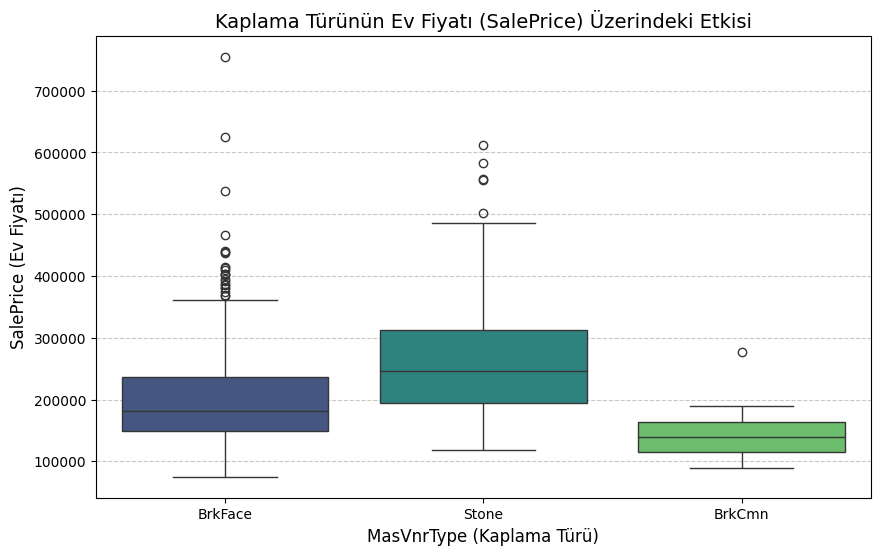

In [82]:
# 1. Her bir kaplama türünün ortalama ev fiyatını (SalePrice) gösterelim
ortalama_fiyatlar = train_data.groupby('MasVnrType')['SalePrice'].mean().sort_values(ascending=False)
fiyat_farki_tablosu = pd.DataFrame(ortalama_fiyatlar).reset_index()
fiyat_farki_tablosu.columns = ['Kaplama Türü', 'Ortalama Ev Fiyatı ($)']

print("### Kaplama Türüne Göre Ortalama Ev Fiyatları ###\n")
print(fiyat_farki_tablosu.to_string(index=False))
print("\n" + "="*50 + "\n")

# 2. Kategorik değişkeni One-Hot Encoding ile sayısal sütunlara (1 ve 0) çevirelim
# Bu sayede her bir kaplama türünün fiyat ile direkt korelasyonunu görebiliriz.
masvnr_encoded = pd.get_dummies(train_data['MasVnrType'], prefix='MasVnr')

# SalePrice sütununu da bu yeni tabloya ekleyelim
masvnr_encoded['SalePrice'] = train_data['SalePrice']

# Şimdi standart Pearson korelasyonunu hesaplayabiliriz
korelasyon_sonuclari = masvnr_encoded.corr()['SalePrice'].sort_values(ascending=False)

print("### Her Bir Kaplama Türünün Ev Fiyatı ile Korelasyonu ###\n")

print("\n" + "="*50 + "\n")

# 3. Etkiyi Görselleştirelim (Boxplot - Kutu Grafiği)
plt.figure(figsize=(10, 6))
sns.boxplot(x='MasVnrType', y='SalePrice', data=train_data, palette='viridis')
plt.title('Kaplama Türünün Ev Fiyatı (SalePrice) Üzerindeki Etkisi', fontsize=14)
plt.xlabel('MasVnrType (Kaplama Türü)', fontsize=12)
plt.ylabel('SalePrice (Ev Fiyatı)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [83]:
# 1. SAYISAL DEĞİŞKENLER: Fiyatla korelasyonu %5'ten (0.05) küçük olanları bulma
sayisal_sutunlar = train_data.select_dtypes(include=['int64', 'float64'])
korelasyonlar = sayisal_sutunlar.corr()['SalePrice'].abs().sort_values()
etkisiz_sayisal = korelasyonlar[korelasyonlar < 0.05] 

print("### SalePrice ile Korelasyonu Neredeyse Sıfır Olan Sayısal Değişkenler ###")
print(etkisiz_sayisal.drop('Id', errors='ignore')) # Id'yi zaten sileceğimiz için listeden çıkarıyoruz
print("\n" + "="*50 + "\n")

# 2. KATEGORİK DEĞİŞKENLER: Verilerin %95'inden fazlası aynı olan (tekdüze) sütunları bulma
kategorik_sutunlar = train_data.select_dtypes(include=['object'])

print("### Fiyatı Ayırt Edemeyecek Kadar Tekdüze Olan Kategorik Değişkenler ###")
for col in kategorik_sutunlar.columns:
    # O sütundaki en çok tekrar eden verinin yüzdesini bul
    en_cok_tekrar_eden_oran = train_data[col].value_counts(normalize=True).max()
    if en_cok_tekrar_eden_oran > 0.95: 
        print(f"{col}: Verilerin %{en_cok_tekrar_eden_oran*100:.1f}'i tamamen aynı değer.")

### SalePrice ile Korelasyonu Neredeyse Sıfır Olan Sayısal Değişkenler ###
BsmtFinSF2      0.011378
BsmtHalfBath    0.016844
MiscVal         0.021190
LowQualFinSF    0.025606
YrSold          0.028923
3SsnPorch       0.044584
MoSold          0.046432
Name: SalePrice, dtype: float64


### Fiyatı Ayırt Edemeyecek Kadar Tekdüze Olan Kategorik Değişkenler ###
Street: Verilerin %99.6'i tamamen aynı değer.
Utilities: Verilerin %99.9'i tamamen aynı değer.
Condition2: Verilerin %99.0'i tamamen aynı değer.
RoofMatl: Verilerin %98.2'i tamamen aynı değer.
Heating: Verilerin %97.8'i tamamen aynı değer.
GarageQual: Verilerin %95.1'i tamamen aynı değer.
GarageCond: Verilerin %96.2'i tamamen aynı değer.


In [84]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. BOŞLUKLARI DOLDURMA (Önceki aşamadaki gibi)
sayisal_sutunlar = train_data.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar = train_data.select_dtypes(include=['object']).columns

if 'SalePrice' in sayisal_sutunlar:
    sayisal_sutunlar = sayisal_sutunlar.drop('SalePrice')

# Sayısalları medyan ile doldur
train_medyanlari = train_data[sayisal_sutunlar].median()
train_data[sayisal_sutunlar] = train_data[sayisal_sutunlar].fillna(train_medyanlari)
test_data[sayisal_sutunlar] = test_data[sayisal_sutunlar].fillna(train_medyanlari)

# Kategorikleri metin ile doldur
train_data[kategorik_sutunlar] = train_data[kategorik_sutunlar].fillna("evde bulunmuyor")
test_data[kategorik_sutunlar] = test_data[kategorik_sutunlar].fillna("evde bulunmuyor")

# ==============================================================================
# 2. ÖZELLİK MÜHENDİSLİĞİ (SİLMEDEN ÖNCE BİRLEŞTİRİYORUZ!)
# ==============================================================================

# Toplam Yaşam Alanı
train_data['TotalSF'] = train_data['GrLivArea'] + train_data['TotalBsmtSF']
test_data['TotalSF'] = test_data['GrLivArea'] + test_data['TotalBsmtSF']

# Toplam Banyo Sayısı (İşte şimdi hata vermeyecek çünkü henüz silmedik!)
train_data['TotalBaths'] = train_data['FullBath'] + (0.5 * train_data['HalfBath']) + train_data['BsmtFullBath'] + (0.5 * train_data['BsmtHalfBath'])
test_data['TotalBaths'] = test_data['FullBath'] + (0.5 * test_data['HalfBath']) + test_data['BsmtFullBath'] + (0.5 * test_data['BsmtHalfBath'])

# Evin Yaşı
train_data['HouseAge'] = train_data['YrSold'] - train_data['YearBuilt']
test_data['HouseAge'] = test_data['YrSold'] - test_data['YearBuilt']

# ==============================================================================
# 3. İŞİ BİTENLERİ VE GEREKSİZLERİ TEK SEFERDE SİLME
# ==============================================================================
silinecekler = [
    'Id', 'Utilities', 'Street', 'Condition2', 'RoofMatl', 'Heating', # Fiyata etkisizler
    'MiscVal', '3SsnPorch', 'MoSold', 'BsmtFinSF2', # Fiyata etkisizler
    'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotRmsAbvGrd', # TotalSF içine girdi
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', # TotalBaths içine girdi
    'YearBuilt', 'YrSold', # HouseAge içine girdi
    'GarageCars', 'GarageYrBlt' # Çoklu bağlantı (VIF) yaratıyordu
]

train_data = train_data.drop(columns=silinecekler, errors='ignore')
test_data = test_data.drop(columns=silinecekler, errors='ignore')

# ==============================================================================
# 4. SON VIF KONTROLÜ
# ==============================================================================
guncel_sayisal = train_data.select_dtypes(include=['int64', 'float64']).columns
if 'SalePrice' in guncel_sayisal:
    guncel_sayisal = guncel_sayisal.drop('SalePrice')

def vif_hesapla(veri_cercevesi):
    vif_tablosu = pd.DataFrame()
    vif_tablosu["Değişken"] = veri_cercevesi.columns
    vif_tablosu["VIF Değeri"] = [variance_inflation_factor(veri_cercevesi.values, i) 
                                 for i in range(veri_cercevesi.shape[1])]
    return vif_tablosu.sort_values(by="VIF Değeri", ascending=False)

print("### Sorunsuz Birleştirme Sonrası Temiz VIF Sonuçları ###\n")
print(vif_hesapla(train_data[guncel_sayisal]).head(10))

### Sorunsuz Birleştirme Sonrası Temiz VIF Sonuçları ###

        Değişken  VIF Değeri
5   YearRemodAdd  115.269669
19       TotalSF   80.435005
3    OverallQual   62.335196
4    OverallCond   34.787167
11  KitchenAbvGr   31.687581
20    TotalBaths   26.222799
10  BedroomAbvGr   21.064966
1    LotFrontage   17.176450
8      BsmtUnfSF   11.360321
13    GarageArea   10.850176


In [85]:
# Train setindeki boş değerleri bul ve sadece 0'dan büyük olanları (boşluk kalanları) filtrele
kalan_bos_train = train_data.isnull().sum()
kalan_bos_train = kalan_bos_train[kalan_bos_train > 0]

# Test setindeki boş değerleri bul ve sadece 0'dan büyük olanları filtrele
kalan_bos_test = test_data.isnull().sum()
kalan_bos_test = kalan_bos_test[kalan_bos_test > 0]

print("### Train Setinde Kalan Boş Değerler ###")
if len(kalan_bos_train) == 0:
    print("✅ Harika! Train setinde hiçbir boş değer kalmadı (0).")
else:
    print("⚠️ Dikkat! Train setinde hala boşluklar var:")
    print(kalan_bos_train)

print("\n" + "="*50 + "\n")

print("### Test Setinde Kalan Boş Değerler ###")
if len(kalan_bos_test) == 0:
    print("✅ Harika! Test setinde hiçbir boş değer kalmadı (0).")
else:
    print("⚠️ Dikkat! Test setinde hala boşluklar var:")
    print(kalan_bos_test)

### Train Setinde Kalan Boş Değerler ###
✅ Harika! Train setinde hiçbir boş değer kalmadı (0).


### Test Setinde Kalan Boş Değerler ###
✅ Harika! Test setinde hiçbir boş değer kalmadı (0).


In [86]:
# Sadece sütun sayılarını net bir şekilde görmek için:
print(f"Train Seti Toplam Sütun Sayısı: {train_data.shape[1]}")
print(f"Test Seti Toplam Sütun Sayısı: {test_data.shape[1]}")

print("\n" + "="*40 + "\n")

# Satır ve sütun sayılarını birlikte (Satır, Sütun) formatında görmek için:
print("### Genel Veri Seti Boyutları ###")
print(f"Train Seti (Satır, Sütun): {train_data.shape}")
print(f"Test Seti (Satır, Sütun): {test_data.shape}")



Train Seti Toplam Sütun Sayısı: 61
Test Seti Toplam Sütun Sayısı: 60


### Genel Veri Seti Boyutları ###
Train Seti (Satır, Sütun): (1460, 61)
Test Seti (Satır, Sütun): (1459, 60)


/tmp/ipykernel_55/2037950247.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=en_cok_etkileyenler.values, y=en_cok_etkileyenler.index, ax=axes[0], palette='viridis')
/tmp/ipykernel_55/2037950247.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=en_az_etkileyenler.values, y=en_az_etkileyenler.index, ax=axes[1], palette='coolwarm')


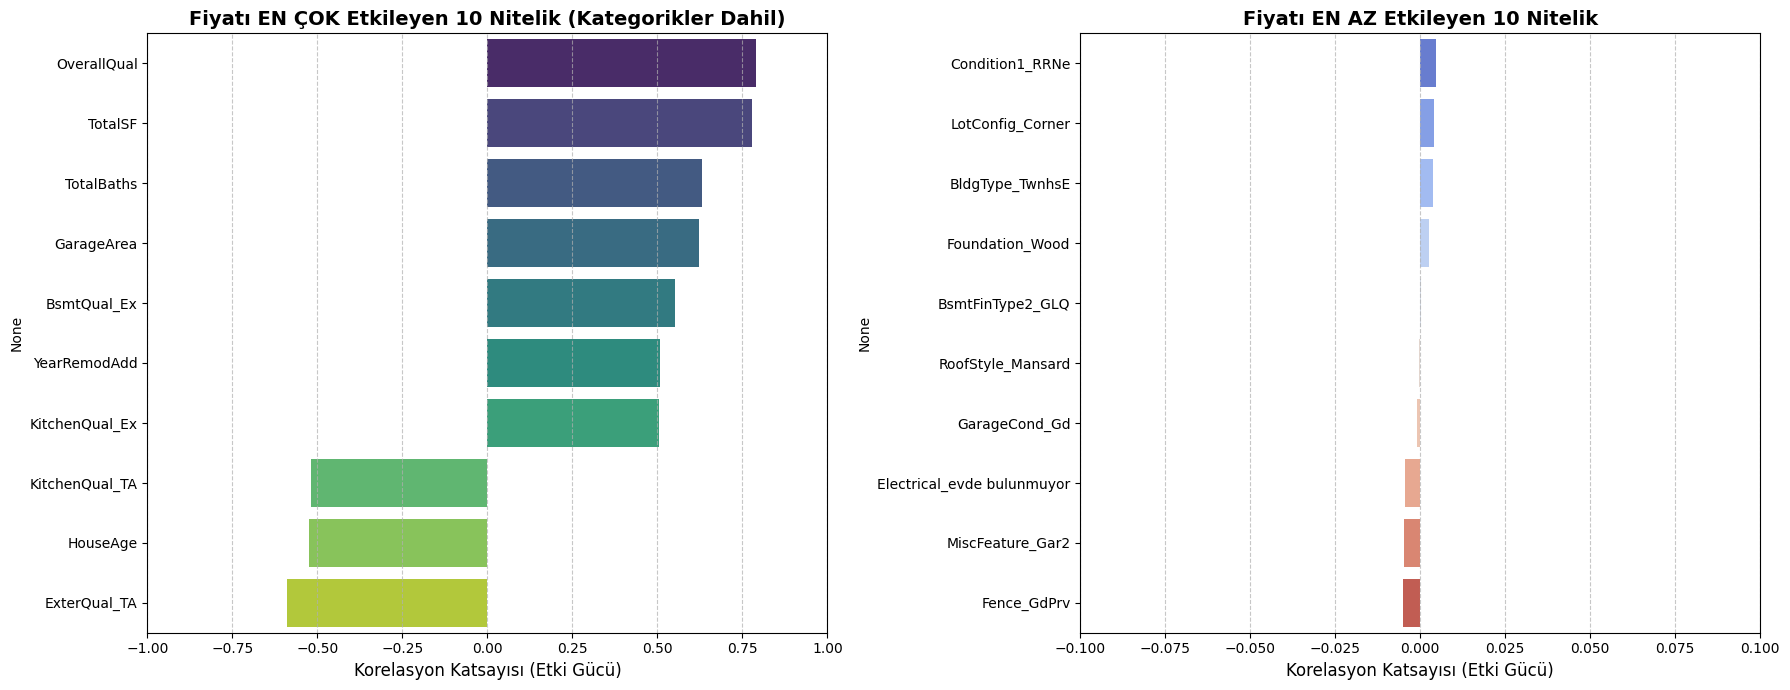

Encoding Sonrası Train Seti Boyutu: (1460, 264)


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. AŞAMA: ENCODING (Metinleri 1 ve 0'lara Dönüştürme)
# ==============================================================================
# Sadece kategorik (metin içeren) sütunları seçiyoruz
kategorik_sutunlar = train_data.select_dtypes(include=['object']).columns

# Hem Train hem Test setine aynı anda One-Hot Encoding uyguluyoruz
# pd.get_dummies fonksiyonu tüm metinleri 1 (True) ve 0 (False) sütunlarına ayırır
train_encoded = pd.get_dummies(train_data, columns=kategorik_sutunlar)
test_encoded = pd.get_dummies(test_data, columns=kategorik_sutunlar)

# Test setinde olmayan ama Train'de olan (veya tam tersi) sütunlar oluşabilir. 
# İki setin sütunlarını eşitliyoruz (eksik olanlara 0 basıyoruz)
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# ==============================================================================
# 2. AŞAMA: KORELASYON HESAPLAMA (Artık her şey sayısal!)
# ==============================================================================
# Hedef değişkenimizle olan ilişkileri hesaplıyoruz
korelasyonlar = train_encoded.corr()['SalePrice'].drop('SalePrice')

# Etki gücünü bulmak için mutlak değerine (negatif/pozitif fark etmez) göre sıralıyoruz
korelasyonlar_sirali = korelasyonlar.abs().sort_values(ascending=False)

# En çok ve en az etkileyen 10 niteliği seçiyoruz
en_cok_etkileyenler = korelasyonlar[korelasyonlar_sirali.head(10).index].sort_values(ascending=False)
en_az_etkileyenler = korelasyonlar[korelasyonlar_sirali.tail(10).index].sort_values(ascending=False)

# ==============================================================================
# 3. AŞAMA: GÖRSELLEŞTİRME
# ==============================================================================
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# 1. GRAFİK: EN ÇOK ETKİLEYENLER
sns.barplot(x=en_cok_etkileyenler.values, y=en_cok_etkileyenler.index, ax=axes[0], palette='viridis')
axes[0].set_title('Fiyatı EN ÇOK Etkileyen 10 Nitelik (Kategorikler Dahil)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Korelasyon Katsayısı (Etki Gücü)', fontsize=12)
axes[0].set_xlim(-1, 1) 
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# 2. GRAFİK: EN AZ ETKİLEYENLER
sns.barplot(x=en_az_etkileyenler.values, y=en_az_etkileyenler.index, ax=axes[1], palette='coolwarm')
axes[1].set_title('Fiyatı EN AZ Etkileyen 10 Nitelik', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Korelasyon Katsayısı (Etki Gücü)', fontsize=12)
axes[1].set_xlim(-0.1, 0.1) # Çok küçük oldukları için ekseni daralttık
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Boyutların ne kadar genişlediğini görelim (Sütun sayımız encoding yüzünden artacak)
print(f"Encoding Sonrası Train Seti Boyutu: {train_encoded.shape}")

In [88]:
# ==============================================================================
# X (Özellikler) ve y (Hedef Değişken) AYRIMI
# ==============================================================================

# Eğitim seti için:
# X_train -> Fiyat hariç her şey (Modelin çalışacağı veriler)
X_train = train_encoded.drop(columns=['SalePrice'])

# y_train -> Sadece Fiyat (Modelin öğrenmeye çalışacağı cevap anahtarı)
y_train = train_encoded['SalePrice']

# Test seti için:
# Test setinde zaten 'SalePrice' sütunu yok (Kaggle bunu bizden tahmin etmemizi istiyor)
X_test = test_encoded.copy()

# Boyutları son kez kontrol edelim
print(f"Eğitim Verisi (X_train) Boyutu: {X_train.shape}")
print(f"Hedef Değişken (y_train) Boyutu: {y_train.shape}")
print(f"Test Verisi (X_test) Boyutu: {X_test.shape}")

Eğitim Verisi (X_train) Boyutu: (1460, 263)
Hedef Değişken (y_train) Boyutu: (1460,)
Test Verisi (X_test) Boyutu: (1459, 264)


In [91]:
# ==============================================================================
# SÜTUN EŞİTLEME VE SON HAZIRLIK 
# ==============================================================================

# 1. Önce X_train ve y_train ayrımını yapalım
X_train = train_encoded.drop(columns=['SalePrice'])
y_train = train_encoded['SalePrice']

# 2. X_test'i kopyalayalım
X_test = test_encoded.copy()

# 3. SENİN YAKALADIĞIN O 1 FARKI SİLME: 
# Test setinde align işleminden kalan sahte 'SalePrice' sütununu atıyoruz
if 'SalePrice' in X_test.columns:
    X_test = X_test.drop(columns=['SalePrice'])

# 4. KRİTİK ADIM: Sütunların sırasını eşitleme
# Makine öğrenmesi modelleri sütunların sadece sayısının değil, SIRASININ da aynı olmasını ister.
# X_test'in sütunlarını, X_train'in sütun sırasına göre yeniden diziyoruz.
X_test = X_test[X_train.columns]

# ==============================================================================
# SON KONTROL 
# ==============================================================================
print(f"Eğitim Sütun Sayısı (X_train): {X_train.shape[1]}")
print(f"Test Sütun Sayısı (X_test):   {X_test.shape[1]}")

if X_train.shape[1] == X_test.shape[1]:
    print("İki veri seti de 263 sütunla tamamen eşitlendi.")
    

Eğitim Sütun Sayısı (X_train): 263
Test Sütun Sayısı (X_test):   263
İki veri seti de 263 sütunla tamamen eşitlendi.
